Note on fine-tuning:
In deep learning, fine-tuning usually refers to starting from a pretrained model (like one trained on ImageNet) and adapting it to a new task by continuing training, often with lower learning rates or by freezing some layers. In this exercise, we are explicitly told not to use fine-tuning or pretrained models. However, adjusting hyperparameters like learning rate, batch size, dropout, and using data augmentation is still part of training from scratch — and is allowed. I have built the VGG11-based model manually and trained it from scratch without loading any pretrained weights.

training_images shape: (1500, 3, 96, 96)
training_labels shape: (1500,)
                                              images  labels
0  [[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...       2
1  [[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...       1
2  [[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...       0
3  [[[218, 216, 216, 216, 218, 218, 216, 217, 220...       0
4  [[[181, 178, 177, 181, 184, 184, 185, 187, 190...       1


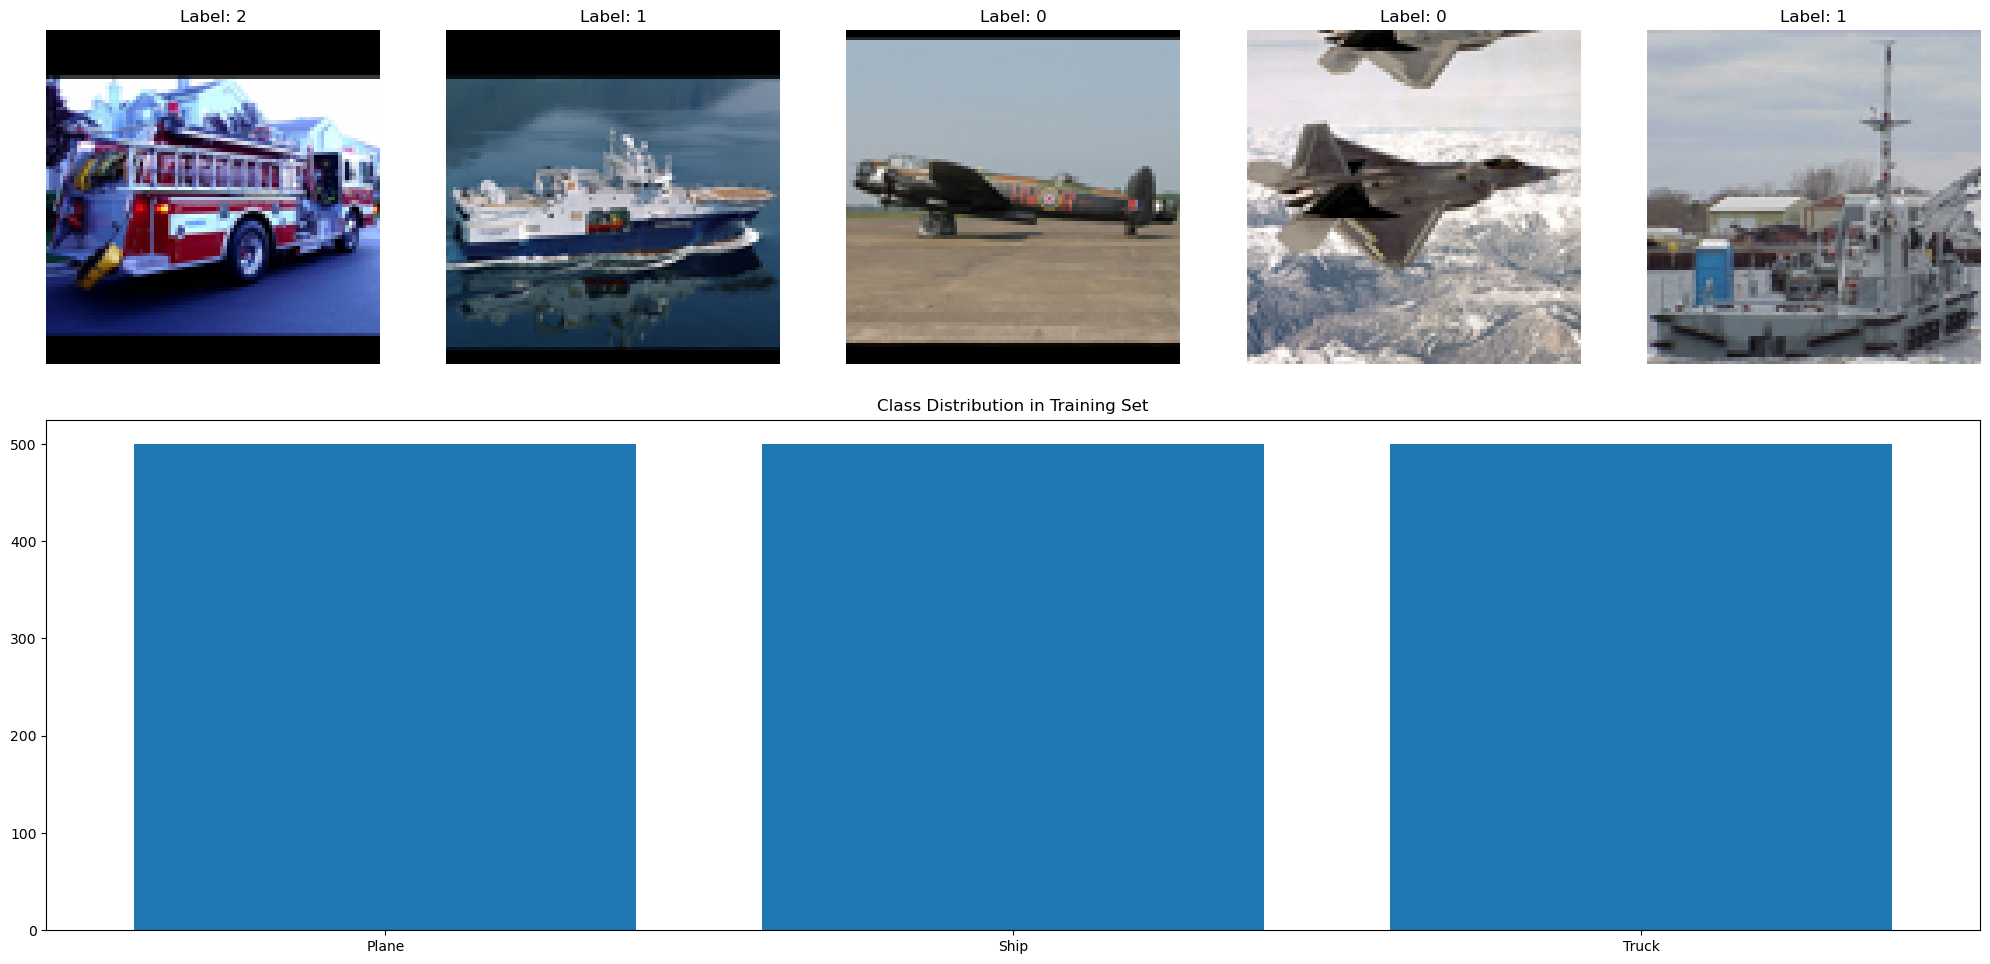

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os

# Add the src folder to the Python path
sys.path.append(os.path.join(os.getcwd(), 'src/'))

training_data = np.load ('data/problem2/training_data.npz')
training_images = training_data ['a' ]
training_labels = training_data ['b']

print('training_images shape:', training_images.shape)
print('training_labels shape:', training_labels.shape)
# converting to dataframe
df = pd.DataFrame({
    'images': list(training_images), # Convert numpy array to list for DataFrame
    'labels': training_labels # Keep labels as is
})

# Display the first few rows of the DataFrame
print(df.head())

import matplotlib.gridspec as gridspec
from collections import Counter

counter = Counter(training_labels)

fig = plt.figure(figsize=(20, 10))
gs = gridspec.GridSpec(2, 1, height_ratios=[1, 1.2])

# Top row: display 5 sample images in a row
gs_top = gridspec.GridSpecFromSubplotSpec(1, 5, subplot_spec=gs[0])
for i in range(5):
    ax = fig.add_subplot(gs_top[i])
    img = training_images[i].transpose(1, 2, 0)  # (C, H, W) -> (H, W, C)
    ax.imshow(img)
    ax.set_title(f"Label: {training_labels[i]}")
    ax.axis('off')

# Bottom row: bar chart for the class distribution
ax_bar = fig.add_subplot(gs[1])
ax_bar.bar(list(counter.keys()), list(counter.values()))
ax_bar.set_title("Class Distribution in Training Set")
ax_bar.set_xticks([0, 1, 2])
ax_bar.set_xticklabels(['Plane', 'Ship', 'Truck'])

plt.tight_layout()
plt.show()


In [2]:
from sklearn.model_selection import train_test_split



# Split indices
train_idx, val_idx = train_test_split(
    np.arange(len(training_labels)),
    test_size=0.2,
    stratify=training_labels,
    random_state=42
)

# Create sets
train_images = training_images[train_idx]
train_labels = training_labels[train_idx]
val_images = training_images[val_idx]
val_labels = training_labels[val_idx]


I kept the 2a config minimal to isolate the effect of BatchNorm. For 2c, I explored how Dropout benefits from additional regularization and LR scheduling.



=== Training: 2a_SGD_no_dropout_no_sched (Batch size: 32) ===


Training 2a_SGD_no_dropout_no_sched_bs32_20250418_180355:  35%|███▌      | 1680/4800 [02:15<04:11, 12.43batch/s, epoch=35/100, phase=val, loss=0.3497, acc=0.8333]  



Early stopping triggered at epoch 35.
Best validation accuracy was 0.9033 at epoch 20.

Best Val Accuracy: 0.9033
Total training time: 135.22s


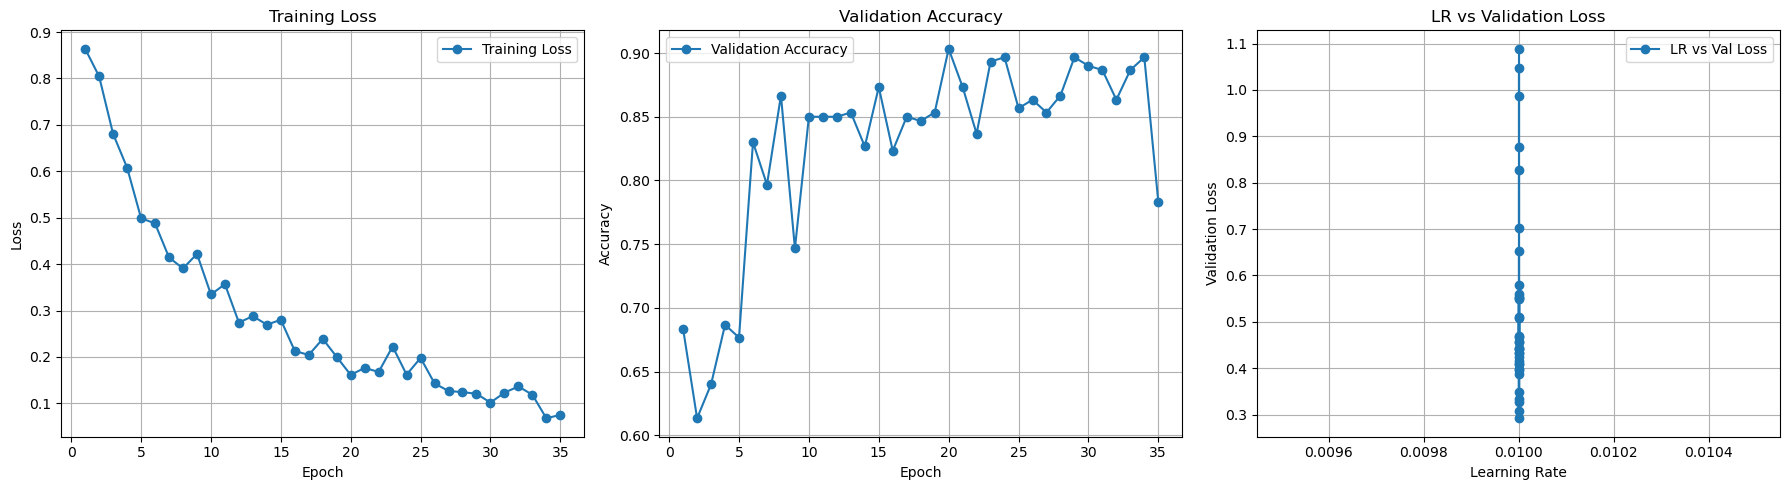

              precision    recall  f1-score   support

       Plane       0.68      0.94      0.79       100
        Ship       0.89      0.59      0.71       100
       Truck       0.86      0.82      0.84       100

    accuracy                           0.78       300
   macro avg       0.81      0.78      0.78       300
weighted avg       0.81      0.78      0.78       300

+------------------------------------------------------+
| Validation Loss: 1.0886, Validation Accuracy: 0.7833 |
+------------------------------------------------------+


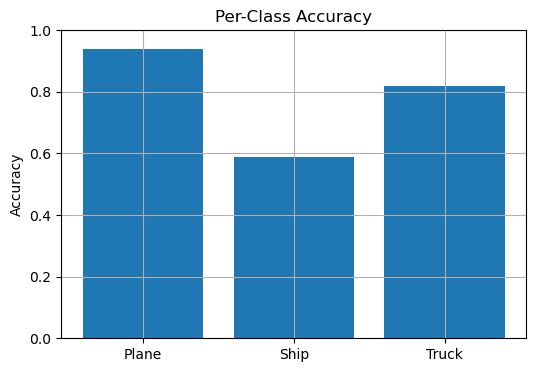



=== Training: 2a_Adam_no_dropout_no_sched (Batch size: 32) ===


Training 2a_Adam_no_dropout_no_sched_bs32_20250418_180612:  29%|██▉       | 1392/4800 [01:56<04:45, 11.95batch/s, epoch=29/100, phase=val, loss=0.3795, acc=0.9167]  



Early stopping triggered at epoch 29.
Best validation accuracy was 0.8933 at epoch 14.

Best Val Accuracy: 0.8933
Total training time: 116.47s


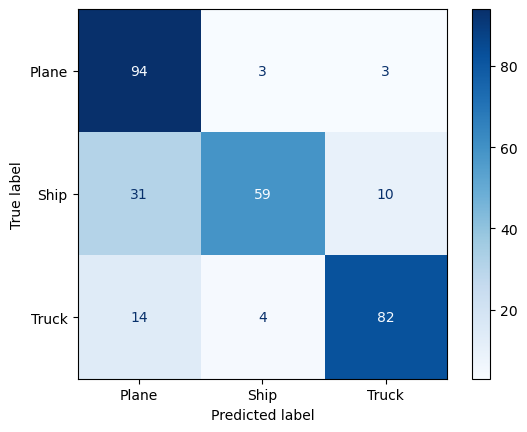

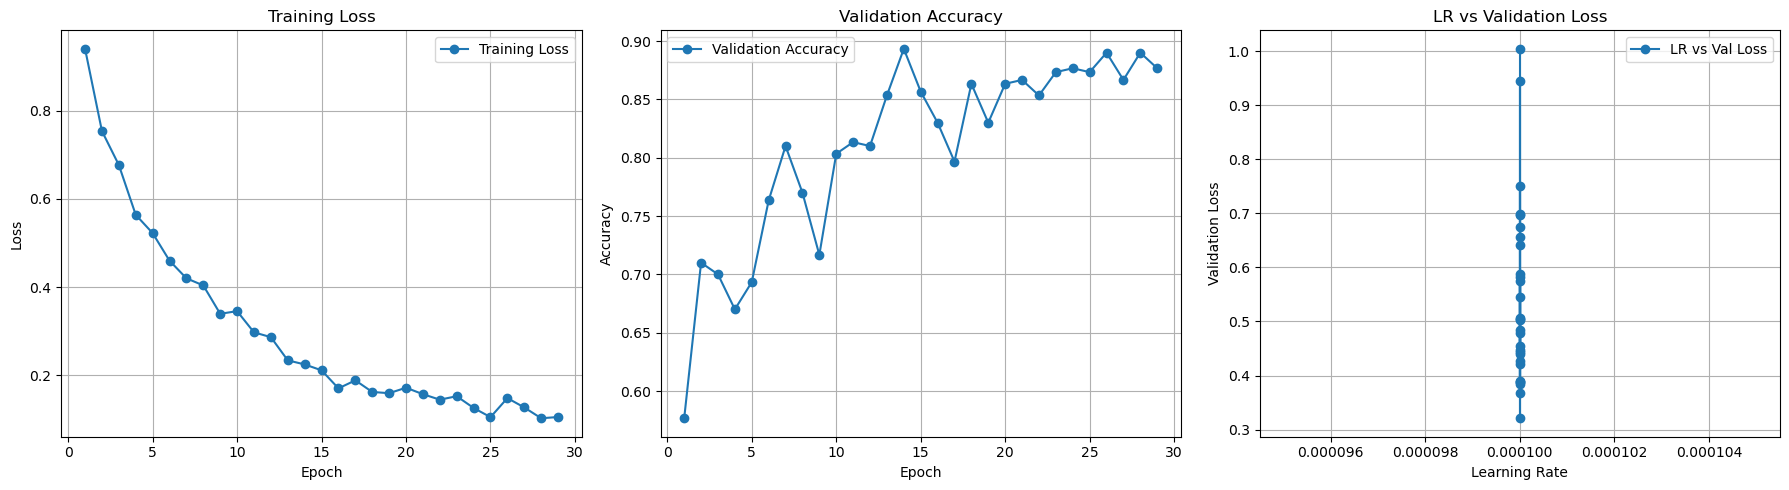

              precision    recall  f1-score   support

       Plane       0.84      0.93      0.88       100
        Ship       0.89      0.85      0.87       100
       Truck       0.90      0.85      0.88       100

    accuracy                           0.88       300
   macro avg       0.88      0.88      0.88       300
weighted avg       0.88      0.88      0.88       300

+------------------------------------------------------+
| Validation Loss: 0.3883, Validation Accuracy: 0.8767 |
+------------------------------------------------------+


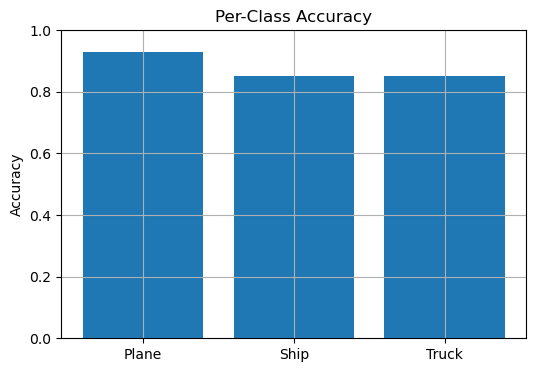



=== Training: 2c_SGD_dropout_sched (Batch size: 32) ===


Training 2c_SGD_dropout_sched_bs32_20250418_180811:  63%|██████▎   | 3024/4800 [04:03<02:22, 12.42batch/s, epoch=63/100, phase=val, loss=0.6155, acc=0.8333]  



Early stopping triggered at epoch 63.
Best validation accuracy was 0.9133 at epoch 48.

Best Val Accuracy: 0.9133
Total training time: 243.40s


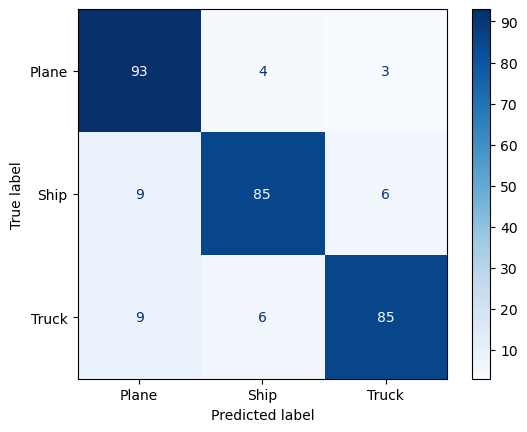

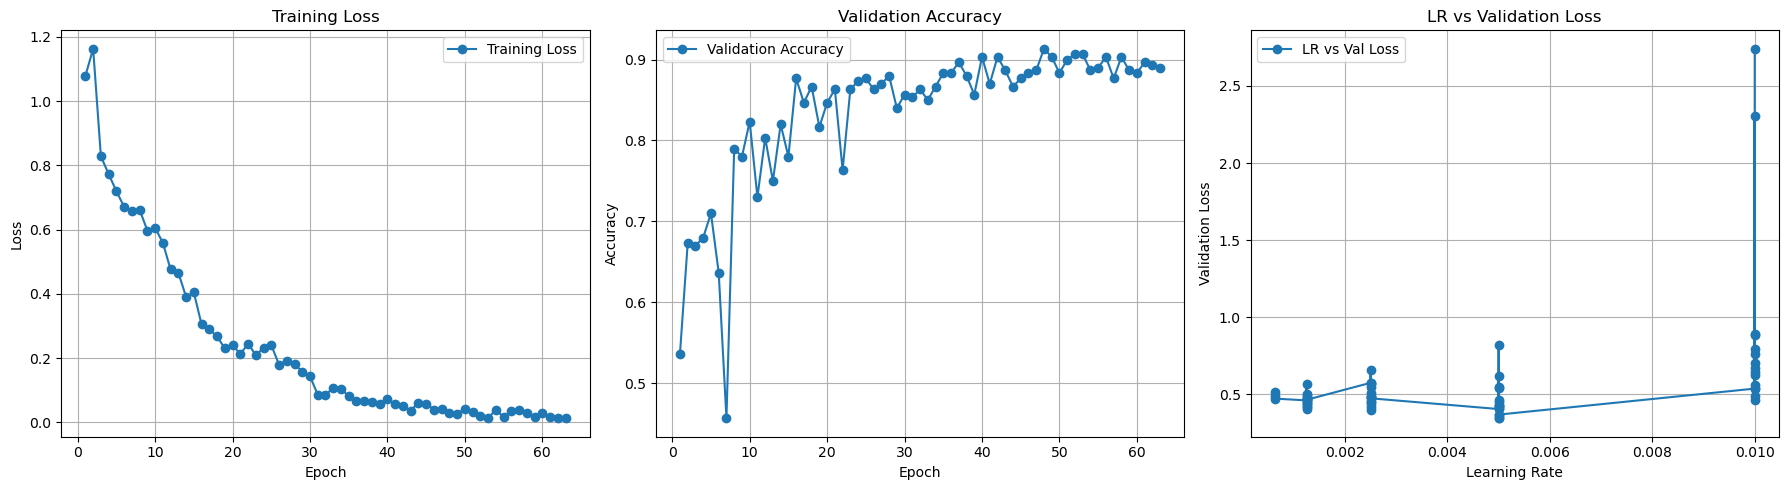

              precision    recall  f1-score   support

       Plane       0.96      0.88      0.92       100
        Ship       0.88      0.88      0.88       100
       Truck       0.84      0.91      0.88       100

    accuracy                           0.89       300
   macro avg       0.89      0.89      0.89       300
weighted avg       0.89      0.89      0.89       300

+------------------------------------------------------+
| Validation Loss: 0.5130, Validation Accuracy: 0.8900 |
+------------------------------------------------------+


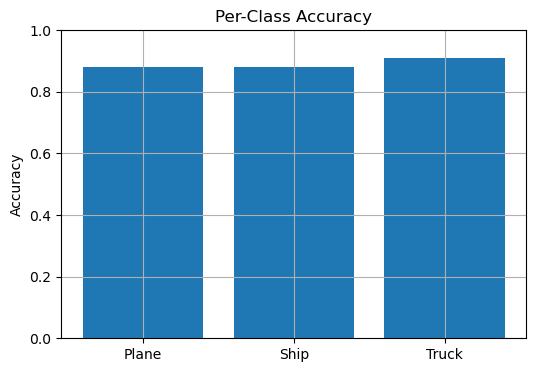



=== Training: 2c_Adam_dropout_sched (Batch size: 32) ===


Training 2c_Adam_dropout_sched_bs32_20250418_181216:  49%|████▉     | 2352/4800 [03:22<03:31, 11.59batch/s, epoch=49/100, phase=val, loss=0.5964, acc=0.8333]  



Early stopping triggered at epoch 49.
Best validation accuracy was 0.9100 at epoch 34.

Best Val Accuracy: 0.9100
Total training time: 202.96s


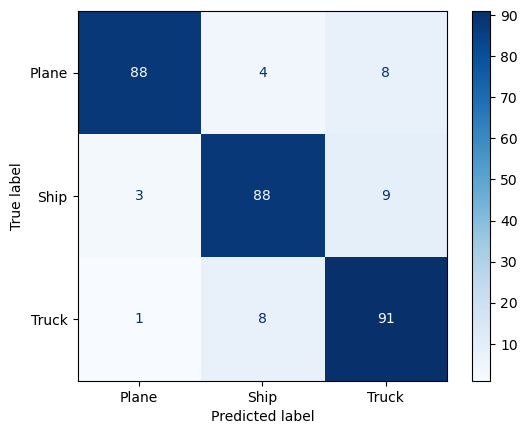

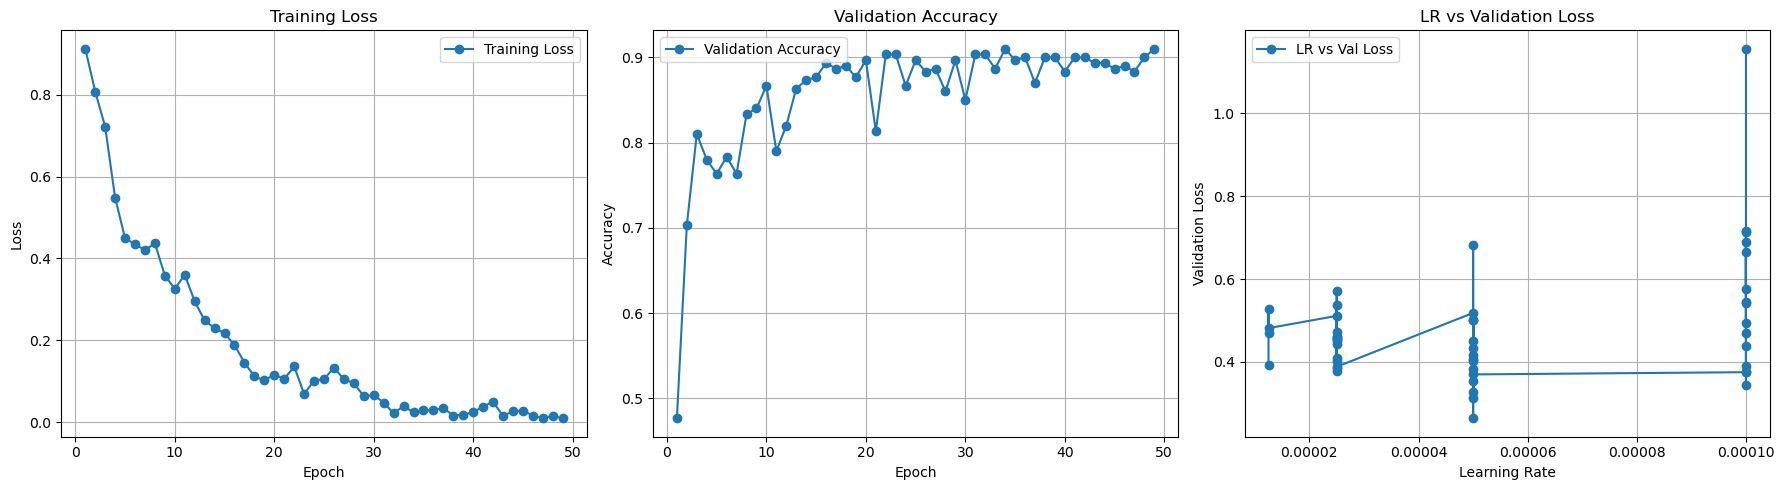

              precision    recall  f1-score   support

       Plane       0.94      0.89      0.91       100
        Ship       0.90      0.94      0.92       100
       Truck       0.90      0.90      0.90       100

    accuracy                           0.91       300
   macro avg       0.91      0.91      0.91       300
weighted avg       0.91      0.91      0.91       300

+------------------------------------------------------+
| Validation Loss: 0.3932, Validation Accuracy: 0.9100 |
+------------------------------------------------------+


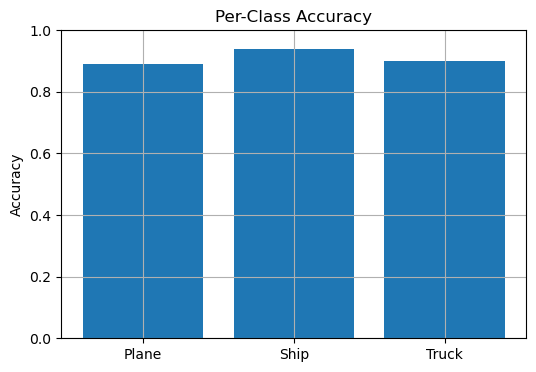

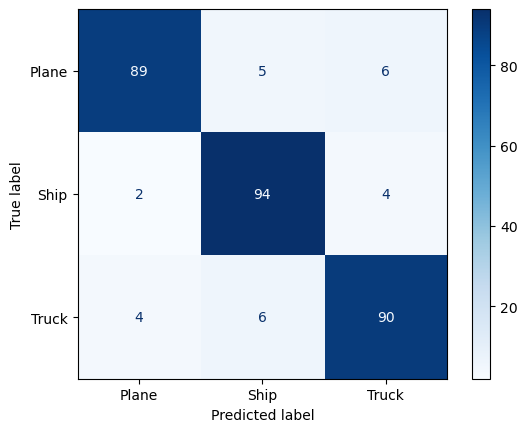

In [3]:
from torch.utils.data import DataLoader
from src.utils import ImageDataset, set_seed, print_framed_metrics
from src.vgg11bn import VGG11BN
from src.train import train_model
from src.evaluation import classification_summary, plot_confusion_matrix, plot_per_class_accuracy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
from torchvision import transforms

# Set seed and device
set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Defining data augmentation transforms for training
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(96, scale=(0.8, 1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

# Define validation transforms (no augmentation)
val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])


# Prepare datasets once
train_dataset = ImageDataset(train_images, train_labels, transform=train_transform)
val_dataset = ImageDataset(val_images, val_labels, transform=val_transform)

# can uncomment the following lines to create datasets again without augmentation
# train_dataset = ImageDataset(train_images, train_labels)
# val_dataset = ImageDataset(val_images, val_labels)

# Define experiment configurations
configs = [
    {
        "name": "2a_SGD_no_dropout_no_sched",
        "dropout": False,
        "optimizer": "sgd",
        "weight_decay": 0,
        "use_scheduler": False,
        "batch_size": 32
    },
    {
        "name": "2a_Adam_no_dropout_no_sched",
        "dropout": False,
        "optimizer": "adam",
        "weight_decay": 0,
        "use_scheduler": False,
        "batch_size": 32
    },
    {
        "name": "2c_SGD_dropout_sched",
        "dropout": True,
        "optimizer": "sgd",
        "weight_decay": 1e-4,
        "use_scheduler": True,
        "batch_size": 32
    },
    {
        "name": "2c_Adam_dropout_sched",
        "dropout": True,
        "optimizer": "adam",
        "weight_decay": 1e-4,
        "use_scheduler": True,
        "batch_size": 32
    }
]



# Run each experiment
for cfg in configs:
    print(f"\n\n=== Training: {cfg['name']} (Batch size: {cfg['batch_size']}) ===")

    # Create dataloaders with specified batch size
    dataloaders = {
        'train': DataLoader(
            train_dataset,
            batch_size=cfg['batch_size'],
            shuffle=True,
            pin_memory=True
        ),
        'val': DataLoader(
            val_dataset,
            batch_size=cfg['batch_size'],
            shuffle=False,
            pin_memory=True
        )
    }

    # Create model and loss function
    model = VGG11BN(num_classes=3, dropout=cfg["dropout"]).to(device)
    criterion = nn.CrossEntropyLoss()
    
    # Setup optimizer based on configuration
    optimizer_name = cfg.get("optimizer", "adam").lower()
    lr = cfg.get("lr", 1e-2 if optimizer_name == 'sgd' else 1e-4) # default lr for SGD and Adam; override in config if needed
    if optimizer_name == "sgd":
        optimizer = optim.SGD(model.parameters(), lr=lr, weight_decay=cfg["weight_decay"],momentum=0.9)
    else:
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=cfg["weight_decay"])

    # Setup scheduler (if any)
    scheduler = StepLR(optimizer, step_size=15, gamma=0.5) if cfg["use_scheduler"] else None

    # Train the model
    trained_model = train_model(
        model=model,
        dataloaders=dataloaders,
        criterion=criterion,
        optimizer=optimizer,
        scheduler=scheduler,
        device=device,
        num_epochs=100,
        model_name=f"{cfg['name']}_bs{cfg['batch_size']}",
        patience=15
    )

    # Evaluate the model
    val_loss, val_acc, y_true, y_pred = classification_summary(
        model=trained_model,
        dataloader=dataloaders["val"],
        criterion=criterion,
        device=device,
        class_names=['Plane', 'Ship', 'Truck']
    )

    print_framed_metrics(val_loss, val_acc)

    plot_per_class_accuracy(y_true, y_pred, class_names=['Plane', 'Ship', 'Truck'],
                        save_path=f"plots/{cfg['name']}_per_class_acc.png")

    # Generate plots
    plot_confusion_matrix(
        trained_model,
        dataloaders['val'],
        device,
        class_names=['Plane', 'Ship', 'Truck'],
        save_path=f"plots/{cfg['name']}_bs{cfg['batch_size']}_confusion_matrix.png"
    )
    





=== Training: 2c_SGD_dropout_sched (Batch size: 32) ===


Training 2c_SGD_dropout_sched_bs32_20250418_181542:  46%|████▌     | 2208/4800 [02:57<03:28, 12.45batch/s, epoch=46/100, phase=val, loss=0.9738, acc=0.8333]  



Early stopping triggered at epoch 46.
Best validation accuracy was 0.9000 at epoch 31.

Best Val Accuracy: 0.9000
Total training time: 177.29s


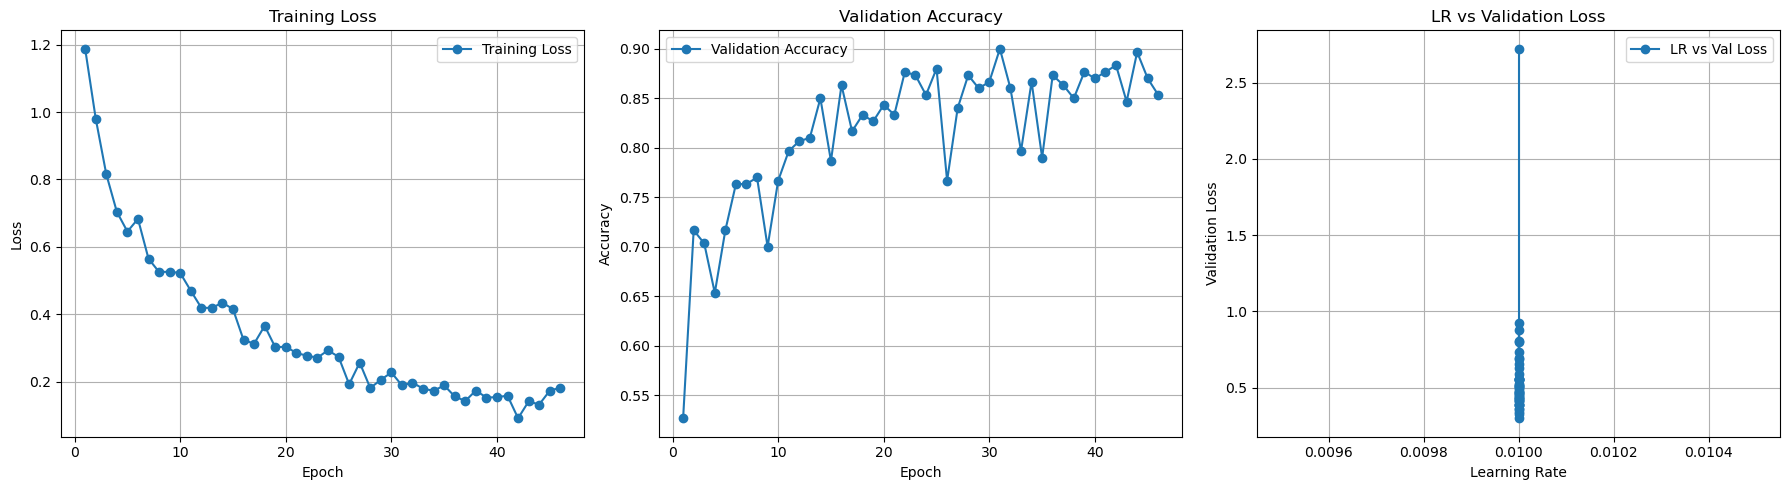

              precision    recall  f1-score   support

       Plane       0.97      0.74      0.84       100
        Ship       0.83      0.90      0.87       100
       Truck       0.79      0.92      0.85       100

    accuracy                           0.85       300
   macro avg       0.87      0.85      0.85       300
weighted avg       0.87      0.85      0.85       300

+------------------------------------------------------+
| Validation Loss: 0.4729, Validation Accuracy: 0.8533 |
+------------------------------------------------------+


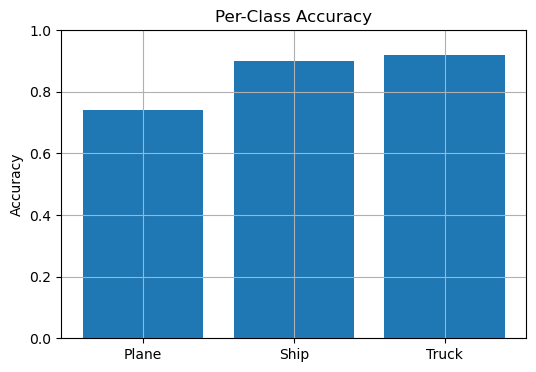



=== Training: 2c_Adam_dropout_sched (Batch size: 32) ===


Training 2c_Adam_dropout_sched_bs32_20250418_181841:  53%|█████▎    | 2544/4800 [03:36<03:11, 11.77batch/s, epoch=53/100, phase=val, loss=0.1004, acc=0.9167]  



Early stopping triggered at epoch 53.
Best validation accuracy was 0.9100 at epoch 38.

Best Val Accuracy: 0.9100
Total training time: 216.16s


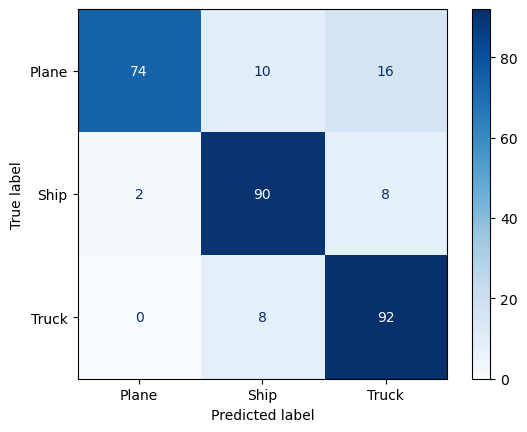

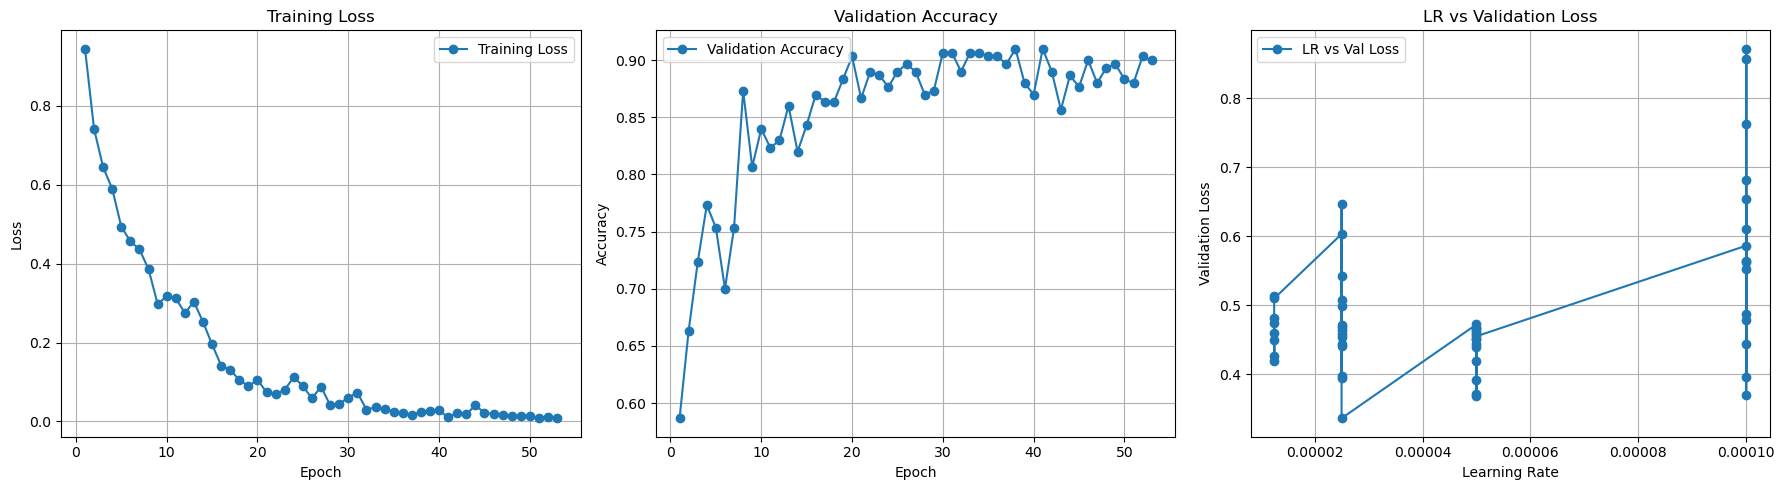

              precision    recall  f1-score   support

       Plane       0.91      0.89      0.90       100
        Ship       0.88      0.92      0.90       100
       Truck       0.92      0.89      0.90       100

    accuracy                           0.90       300
   macro avg       0.90      0.90      0.90       300
weighted avg       0.90      0.90      0.90       300

+------------------------------------------------------+
| Validation Loss: 0.4505, Validation Accuracy: 0.9000 |
+------------------------------------------------------+


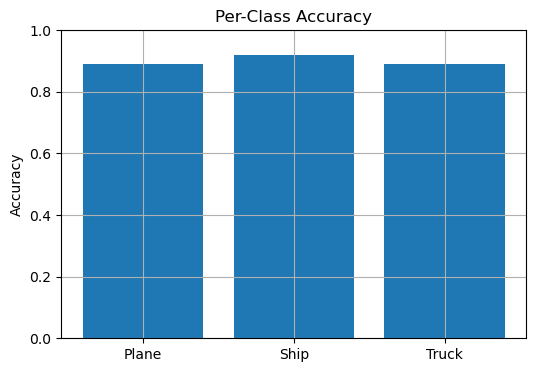

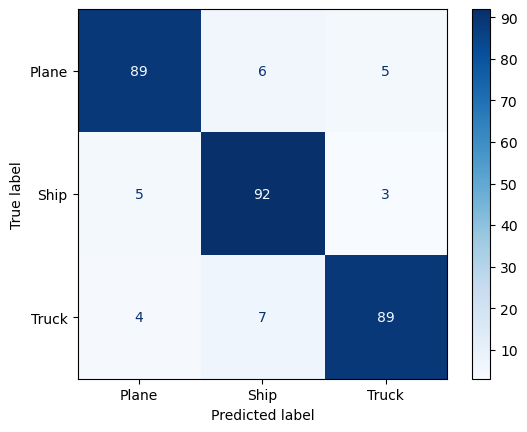

In [4]:
from torch.utils.data import DataLoader
from src.utils import ImageDataset, set_seed, print_framed_metrics
from src.vgg11bn import VGG11BN
from src.train import train_model
from src.evaluation import classification_summary, plot_confusion_matrix, plot_per_class_accuracy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
from torchvision import transforms

# Set seed and device
set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Defining data augmentation transforms for training
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(96, scale=(0.8, 1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

# Define validation transforms (no augmentation)
val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])


# Prepare datasets once
train_dataset = ImageDataset(train_images, train_labels, transform=train_transform)
val_dataset = ImageDataset(val_images, val_labels, transform=val_transform)

# can uncomment the following lines to create datasets again without augmentation
# train_dataset = ImageDataset(train_images, train_labels)
# val_dataset = ImageDataset(val_images, val_labels)

# Define experiment configurations
configs = [
    {
        "name": "2c_SGD_dropout_sched",
        "dropout": True,
        "optimizer": "sgd",
        "weight_decay": 1e-4,
        "use_scheduler": False,
        "batch_size": 32
    },
    {
        "name": "2c_Adam_dropout_sched",
        "dropout": True,
        "optimizer": "adam",
        "weight_decay": 1e-4,
        "use_scheduler": True,
        "batch_size": 32
    }
]



# Run each experiment
for cfg in configs:
    print(f"\n\n=== Training: {cfg['name']} (Batch size: {cfg['batch_size']}) ===")

    # Create dataloaders with specified batch size
    dataloaders = {
        'train': DataLoader(
            train_dataset,
            batch_size=cfg['batch_size'],
            shuffle=True,
            pin_memory=True
        ),
        'val': DataLoader(
            val_dataset,
            batch_size=cfg['batch_size'],
            shuffle=False,
            pin_memory=True
        )
    }

    # Create model and loss function
    model = VGG11BN(num_classes=3, dropout=cfg["dropout"]).to(device)
    criterion = nn.CrossEntropyLoss()
    
    # Setup optimizer based on configuration
    optimizer_name = cfg.get("optimizer", "adam").lower()
    lr = cfg.get("lr", 1e-2 if optimizer_name == 'sgd' else 1e-4) # default lr for SGD and Adam; override in config if needed
    if optimizer_name == "sgd":
        optimizer = optim.SGD(model.parameters(), lr=lr, weight_decay=cfg["weight_decay"],momentum=0.9)
    else:
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=cfg["weight_decay"])

    # Setup scheduler (if any)
    scheduler = StepLR(optimizer, step_size=15, gamma=0.5) if cfg["use_scheduler"] else None

    # Train the model
    trained_model = train_model(
        model=model,
        dataloaders=dataloaders,
        criterion=criterion,
        optimizer=optimizer,
        scheduler=scheduler,
        device=device,
        num_epochs=100,
        model_name=f"{cfg['name']}_bs{cfg['batch_size']}",
        patience=15
    )

    # Evaluate the model
    val_loss, val_acc, y_true, y_pred = classification_summary(
        model=trained_model,
        dataloader=dataloaders["val"],
        criterion=criterion,
        device=device,
        class_names=['Plane', 'Ship', 'Truck']
    )

    print_framed_metrics(val_loss, val_acc)

    plot_per_class_accuracy(y_true, y_pred, class_names=['Plane', 'Ship', 'Truck'],
                        save_path=f"plots/{cfg['name']}_per_class_acc.png")

    # Generate plots
    plot_confusion_matrix(
        trained_model,
        dataloaders['val'],
        device,
        class_names=['Plane', 'Ship', 'Truck'],
        save_path=f"plots/{cfg['name']}_bs{cfg['batch_size']}_confusion_matrix.png"
    )
    



In [ ]:
from torch.utils.data import DataLoader
from src.utils import ImageDataset, set_seed, print_framed_metrics
from src.vgg11bn import VGG11BN
from src.train import train_model
from src.evaluation import classification_summary, plot_confusion_matrix, plot_per_class_accuracy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
from torchvision import transforms

# Set seed and device
set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Defining data augmentation transforms for training
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(96, scale=(0.8, 1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

# Define validation transforms (no augmentation)
val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])


# Prepare datasets once
train_dataset = ImageDataset(train_images, train_labels, transform=train_transform)
val_dataset = ImageDataset(val_images, val_labels, transform=val_transform)

# can uncomment the following lines to create datasets again without augmentation
# train_dataset = ImageDataset(train_images, train_labels)
# val_dataset = ImageDataset(val_images, val_labels)

# Define experiment configurations
configs = [
    {
        "name": "2c_Adam_dropout_sched",
        "dropout": True,
        "optimizer": "adam",
        "weight_decay": 1e-4,
        "use_scheduler": False,
        "batch_size": 32
    }
]



# Run each experiment
for cfg in configs:
    print(f"\n\n=== Training: {cfg['name']} (Batch size: {cfg['batch_size']}) ===")

    # Create dataloaders with specified batch size
    dataloaders = {
        'train': DataLoader(
            train_dataset,
            batch_size=cfg['batch_size'],
            shuffle=True,
            pin_memory=True
        ),
        'val': DataLoader(
            val_dataset,
            batch_size=cfg['batch_size'],
            shuffle=False,
            pin_memory=True
        )
    }

    # Create model and loss function
    model = VGG11BN(num_classes=3, dropout=cfg["dropout"]).to(device)
    criterion = nn.CrossEntropyLoss()
    
    # Setup optimizer based on configuration
    optimizer_name = cfg.get("optimizer", "adam").lower()
    lr = cfg.get("lr", 1e-2 if optimizer_name == 'sgd' else 5e-4) # default lr for SGD and Adam; override in config if needed
    if optimizer_name == "sgd":
        optimizer = optim.SGD(model.parameters(), lr=lr, weight_decay=cfg["weight_decay"],momentum=0.9)
    else:
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=cfg["weight_decay"])

    # Setup scheduler (if any)
    scheduler = StepLR(optimizer, step_size=15, gamma=0.5) if cfg["use_scheduler"] else None

    # Train the model
    trained_model = train_model(
        model=model,
        dataloaders=dataloaders,
        criterion=criterion,
        optimizer=optimizer,
        scheduler=scheduler,
        device=device,
        num_epochs=100,
        model_name=f"{cfg['name']}_bs{cfg['batch_size']}",
        patience=15
    )

    # Evaluate the model
    val_loss, val_acc, y_true, y_pred = classification_summary(
        model=trained_model,
        dataloader=dataloaders["val"],
        criterion=criterion,
        device=device,
        class_names=['Plane', 'Ship', 'Truck']
    )

    print_framed_metrics(val_loss, val_acc)

    plot_per_class_accuracy(y_true, y_pred, class_names=['Plane', 'Ship', 'Truck'],
                        save_path=f"plots/{cfg['name']}_per_class_acc.png")

    # Generate plots
    plot_confusion_matrix(
        trained_model,
        dataloaders['val'],
        device,
        class_names=['Plane', 'Ship', 'Truck'],
        save_path=f"plots/{cfg['name']}_bs{cfg['batch_size']}_confusion_matrix.png"
    )
    



C:\Users\tihas\AppData\Local\Temp\ipykernel_14428\249698010.py:70: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path))


              precision    recall  f1-score   support

       Plane       0.94      0.87      0.90       100
        Ship       0.90      0.90      0.90       100
       Truck       0.88      0.94      0.91       100

    accuracy                           0.90       300
   macro avg       0.90      0.90      0.90       300
weighted avg       0.90      0.90      0.90       300


🧪 Best Model Evaluation:
Validation Loss: 0.4400, Accuracy: 0.9033


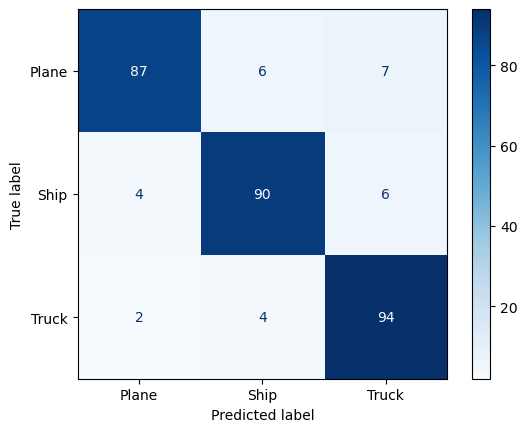

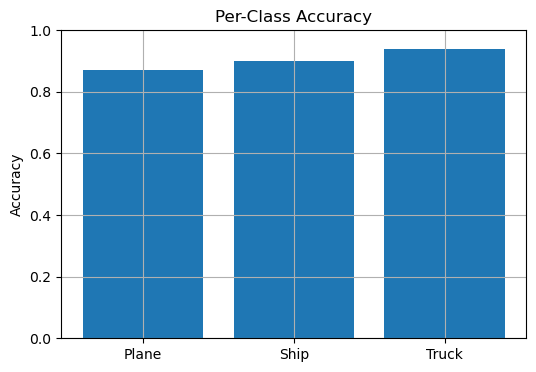

In [7]:
# === Load and evaluate best saved model ===

import torch
from src.vgg11bn import VGG11BN
from src.evaluation import classification_summary, plot_confusion_matrix, plot_multiclass_roc
from torch import nn


from torch.utils.data import DataLoader
from src.utils import ImageDataset, set_seed, print_framed_metrics
from src.vgg11bn import VGG11BN
from src.train import train_model
from src.evaluation import classification_summary, plot_confusion_matrix, plot_per_class_accuracy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
from torchvision import transforms

# Defining data augmentation transforms for training
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(96, scale=(0.8, 1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

# Define validation transforms (no augmentation)
val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])


# Prepare datasets once
train_dataset = ImageDataset(train_images, train_labels, transform=train_transform)
val_dataset = ImageDataset(val_images, val_labels, transform=val_transform)
# Create dataloaders with specified batch size
dataloaders = {
    'train': DataLoader(
        train_dataset,
        batch_size=32,
        shuffle=True,
        pin_memory=True
    ),
    'val': DataLoader(
        val_dataset,
        batch_size=32,
        shuffle=False,
        pin_memory=True
    )
}


# Set seed and device
set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# === Replace this with the actual path to your best model ===
# best_model_path = "models/2c_Adam_dropout_sched_bs32_20250418_15043_best.pth"
best_model_path = "C:/Users/tihas/OneDrive - UiT Office 365/A_UIT/FYS-3033/HOME_EXAM/FYS3033DL/models/2c_Adam_dropout_sched_bs32_20250418_150043_best.pth"
# best_model_path = "C:/Users/tihas/OneDrive - UiT Office 365/A_UIT/FYS-3033/HOME_EXAM/FYS3033DL/models/2c_SGD_dropout_sched_bs32_20250418_145552_best.pth"
# === Rebuild the same model architecture as used during training ===
model = VGG11BN(num_classes=3, dropout=True)  # <-- Set dropout=True/False as used in training
model.load_state_dict(torch.load(best_model_path))
model.to(device)
model.eval()

# === Loss function (same as training) ===
criterion = nn.CrossEntropyLoss()

# === Evaluate and print classification summary ===
val_loss, val_acc, y_true, y_pred = classification_summary(
    model=model,
    dataloader=dataloaders["val"],
    criterion=criterion,
    device=device,
    class_names=['Plane', 'Ship', 'Truck']
)

print(f"\n🧪 Best Model Evaluation:\nValidation Loss: {val_loss:.4f}, Accuracy: {val_acc:.4f}")

# === Optional plots ===
plot_confusion_matrix(model, dataloaders['val'], device, class_names=['Plane', 'Ship', 'Truck'])
plot_per_class_accuracy(y_true, y_pred, class_names=['Plane', 'Ship', 'Truck'])


In [ ]:
import os
from glob import glob

# === Automatically evaluate all _best.pth models in the models folder ===
model_dir = "models"
model_paths = glob(os.path.join(model_dir, "*.pth"))

print(f"\ Found {len(model_paths)} best model(s) to evaluate:\n")

for best_model_path in sorted(model_paths):
    # Detect if dropout was used based on filename (you can tweak this logic if needed)
    use_dropout = "dropout" in best_model_path.lower()

    print(f"\n🔍 Evaluating: {os.path.basename(best_model_path)}")
    model = VGG11BN(num_classes=3, dropout=use_dropout)
    model.load_state_dict(torch.load(best_model_path, map_location=device))
    model.to(device)
    model.eval()

    criterion = nn.CrossEntropyLoss()

    val_loss, val_acc, y_true, y_pred = classification_summary(
        model=model,
        dataloader=dataloaders["val"],
        criterion=criterion,
        device=device,
        class_names=['Plane', 'Ship', 'Truck']
    )

    print(f"Validation Loss: {val_loss:.4f}, Accuracy: {val_acc:.4f}")

    # Optional plots
    plot_confusion_matrix(model, dataloaders['val'], device, class_names=['Plane', 'Ship', 'Truck'])
    plot_per_class_accuracy(y_true, y_pred, class_names=['Plane', 'Ship', 'Truck'])

    print("-" * 60)


During experimentation, I observed minor variations in performance when training the same model setup on different machines (e.g., local vs remote). While seed setting and deterministic flags were applied, hardware differences (e.g., GPU type, cuDNN backend, etc.) likely contributed to nondeterministic behavior. This is a known challenge in deep learning reproducibility and did not affect overall conclusions drawn from the trends observed across experiments.

2c

C:\Users\tihas\AppData\Local\Temp\ipykernel_14308\1380015200.py:47: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path, map_locat

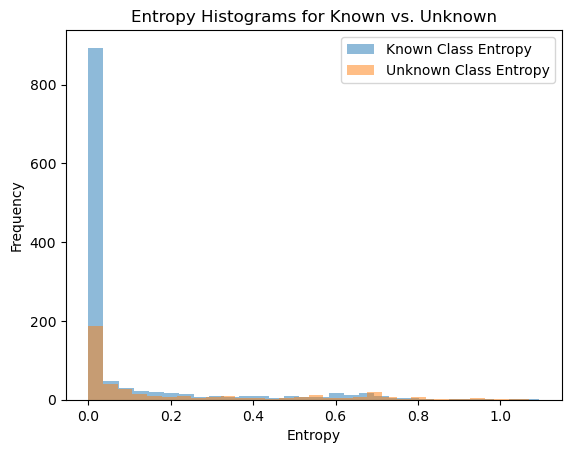

 Entropy histograms for known and unknown classes plotted successfully.


In [1]:
import torch
import torch.nn.functional as F
import numpy as np
from torch.utils.data import DataLoader, Dataset
from src.utils import compute_entropy, ImageDataset, set_seed
from src.evaluation import plot_entropy_hist
from src.vgg11bn import VGG11BN

# Set seed and device
set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Load data with real known/unknown labels ---
eval_data = np.load('data/problem2/new_evaluation_data_with_labels.npz')
eval_images = eval_data['a']          # shape: (N, 96, 96, 3)
eval_labels = eval_data['b']          # shape: (N,)

# Split data into known and unknown using labels
known_images = eval_images[eval_labels != 3]
unknown_images = eval_images[eval_labels == 3]


# --- DataLoaders ---
known_loader = DataLoader(ImageDataset(known_images), batch_size=32, shuffle=False)
unknown_loader = DataLoader(ImageDataset(unknown_images), batch_size=32, shuffle=False)

# --- MC Dropout Prediction ---
def mc_dropout_prediction(model, x_batch, mc_passes=10):
    model.train()  # keep dropout active

    probs_list = []
    with torch.no_grad():
        for _ in range(mc_passes):
            out = model(x_batch.to(device))
            sm = F.softmax(out, dim=1)
            probs_list.append(sm)
    probs_mc = torch.stack(probs_list, dim=0)       # (mc_passes, batch_size, num_classes)
    mean_probs = torch.mean(probs_mc, dim=0)        # (batch_size, num_classes)
    return mean_probs

# --- Uncertainty Estimation ---
entropies_known = []
entropies_unknown = []

best_model_path = "C:/Users/tihas/OneDrive - UiT Office 365/A_UIT/FYS-3033/HOME_EXAM/FYS3033DL/models/2c_Adam_dropout_sched_bs32_20250418_181216_best.pth"
model = VGG11BN(num_classes=3, dropout=True)  # Load the same model architecture
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.to(device)
# Known class predictions
for inputs in known_loader:
    inputs = inputs.to(device)
    mean_probs = mc_dropout_prediction(model, inputs, mc_passes=10)
    entropies_known.extend([compute_entropy(p.cpu().numpy()) for p in mean_probs])

# Unknown class predictions
for inputs in unknown_loader:
    inputs = inputs.to(device)
    mean_probs = mc_dropout_prediction(model, inputs, mc_passes=10)
    entropies_unknown.extend([compute_entropy(p.cpu().numpy()) for p in mean_probs])

# --- Plot entropy histograms ---
plot_entropy_hist(entropies_known, entropies_unknown)

print(" Entropy histograms for known and unknown classes plotted successfully.")


In [2]:
# 2 e)
import numpy as np

# Convert lists to numpy arrays
entropies_known = np.array(entropies_known)
entropies_unknown = np.array(entropies_unknown)

# Let's pick a threshold halfway between the means
mean_known = np.mean(entropies_known)
mean_unknown = np.mean(entropies_unknown)
threshold = (mean_known + mean_unknown) / 2

print(f"Mean Entropy (Known):   {mean_known:.4f}")
print(f"Mean Entropy (Unknown): {mean_unknown:.4f}")
print(f"Selected Threshold:      {threshold:.4f}")

# Apply threshold
# True unknowns detected = entropy > threshold
unknown_detected = np.sum(entropies_unknown > threshold)
unknown_total = len(entropies_unknown)

# False positives = known mistakenly removed
known_wrongly_rejected = np.sum(entropies_known > threshold)
known_total = len(entropies_known)

# Report
print(f"\n Detected {unknown_detected} out of {unknown_total} unknown-class images.")
print(f" Mistakenly removed {known_wrongly_rejected} out of {known_total} known-class images.")

# Optional: Save threshold for 2f
entropy_threshold = threshold


Mean Entropy (Known):   0.0846
Mean Entropy (Unknown): 0.2044
Selected Threshold:      0.1445

 Detected 145 out of 413 unknown-class images.
 Mistakenly removed 193 out of 1187 known-class images.


In [3]:
# **Solution Code for Problem 2e**

import numpy as np

# Let entropies_known, entropies_unknown be from previous steps.
# We'll pick a threshold such that e.g., 95th percentile of known entropies.
threshold = np.percentile(entropies_known, 95)

print(f"Chosen entropy threshold: {threshold:.4f}")

# Classify known set:
known_predictions = [1 if e > threshold else 0 for e in entropies_known]
# 0 => predicted known, 1 => predicted unknown

# Classify unknown set:
unknown_predictions = [1 if e > threshold else 0 for e in entropies_unknown]

# How many unwanted class samples (truly unknown) were correctly detected?
correctly_detected_unknown = sum(unknown_predictions)  # 1 means flagged unknown

# How many wanted class samples (truly known) were mistakenly removed?
# i.e., how many known samples got predicted unknown?
mistakenly_removed_known = sum(known_predictions)

print(f"Unwanted class samples correctly detected: {correctly_detected_unknown}")
print(f"Wanted class samples mistakenly removed: {mistakenly_removed_known}")


Chosen entropy threshold: 0.6037
Unwanted class samples correctly detected: 59
Wanted class samples mistakenly removed: 60


In [ ]:

eval_labels = eval_labels.astype(int)

# Separate entropies by known and unwanted classes (assume label 3 corresponds to the unwanted class 'bird')
entropies_known = [e for e, l in zip(entropies, new_eval_labels) if l != 3]
entropies_unwanted = [e for e, l in zip(entropies, new_eval_labels) if l == 3]


# Plot histograms of entropies for known and unwanted classes
plt.figure(figsize=(10, 6))
plt.hist(entropies_known, bins=30, alpha=0.7, label='Known Classes', color='blue')
plt.hist(entropies_unwanted, bins=30, alpha=0.7, label='Unwanted Class', color='red')
plt.axvline(entropy_threshold, color='black', linestyle='--', label='Threshold')
plt.xlabel('Entropy')
plt.ylabel('Frequency')
plt.title('Entropy Distribution for Known and Unwanted Classes')
plt.legend()
plt.grid(True)
plt.show()


NameError: name 'entropies' is not defined